<a href="https://colab.research.google.com/github/tabrejansary/ML-Assignments/blob/main/Lab04/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="marketing_campaign")

print(df.head())


Saving Lab Session Data.xlsx to Lab Session Data (1).xlsx
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00       58       635  ...                  7   
1  2014-08-03 00:00:00       38        11  ...                  5   
2           21-08-2013       26       426  ...                  4   
3  2014-10-02 00:00:00       26        11  ...                  6   
4           19-01-2014       94       173  ...                  5   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1 

In [ ]:
# A1 - I have used Chatgpt for this question.
import numpy as np

def classify_Features(df):
    feature_types = {
        "ID": "Nominal",
        "Year_Birth": "Interval",
        "Education": "Ordinal",
        "Marital_Status": "Nominal",
        "Income": "Ratio",
        "Kidhome": "Ratio",
        "Teenhome": "Ratio",
        "Dt_Customer": "Interval",
        "Recency": "Ratio",
        "MntWines": "Ratio",
        "MntFruits": "Ratio",
        "MntMeatProducts": "Ratio",
        "MntFishProducts": "Ratio",
        "MntSweetProducts": "Ratio",
        "MntGoldProds": "Ratio",
        "NumDealsPurchases": "Ratio",
        "NumWebPurchases": "Ratio",
        "NumCatalogPurchases": "Ratio",
        "NumStorePurchases": "Ratio",
        "NumWebVisitsMonth": "Ratio",
        "AcceptedCmp3": "Nominal",
        "AcceptedCmp4": "Nominal",
        "AcceptedCmp5": "Nominal",
        "AcceptedCmp1": "Nominal",
        "AcceptedCmp2": "Nominal",
        "Complain": "Nominal",
        "Z_CostContact": "Ratio",
        "Z_Revenue": "Ratio",
        "Response": "Nominal"
    }

    return pd.DataFrame(
        list(feature_types.items()),
        columns=["Feature", "Measurement Type"]
    )

#A2 - Used Chatgpt for this question as well.

def Label_encode(df, column):
    from sklearn.preprocessing import LabelEncoder

    encoder = LabelEncoder()
    encoded = encoder.fit_transform(df[column])

    return encoded


def one_hot_encode(df, column):
    from sklearn.preprocessing import OneHotEncoder

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = encoder.fit_transform(df[[column]])

    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out([column]),
        index=df.index
    )

    return encoded_df

#A3 - For th is also used chatgpt to get the code snippet
def Encode_dataset(df):
    encoded_df = df.copy()

    education_encoded = Label_encode(df, "Education")
    encoded_df["Education"] = education_encoded

    marital_encoded = one_hot_encode(df, "Marital_Status")

    encoded_df = pd.concat(
        [encoded_df.drop(columns=["Marital_Status"]), marital_encoded],
        axis=1
    )

    return encoded_df

# A4 - with the help of chatgpt
def minkowski_distance(point1, point2, p):
    if len(point1) != len(point2):
        raise ValueError("Both points must have the same dimensions")

    if p <= 0:
        raise ValueError("p must be greater than 0")

    total = 0

    for i in range(len(point1)):
        total += abs(point1[i] - point2[i]) ** p

    return total ** (1 / p)


# A7 - With Chatpgt help
def Dot_product(A, B):
    if len(A) != len(B):
        raise ValueError("Vectors must have the same dimensions")

    result = 0

    for i in range(len(A)):
        result += A[i] * B[i]

    return result


def euclidean_Norm(A):
    sum_of_squares = 0

    for value in A:
        sum_of_squares += value ** 2

    return sum_of_squares ** 0.5

# A8 - From Chatgpt
def calculate_mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)


def calculate_variance(data):
    mean = calculate_mean(data)
    total = 0

    for value in data:
        total += (value - mean) ** 2

    return total / len(data)


def calculate_std(data):
    variance = calculate_variance(data)

    return variance ** 0.5


def calculate_dataset_statistics(df):
    numeric_data = df.select_dtypes(include="number")
    results = {}

    for column in numeric_data.columns:
        values = numeric_data[column].dropna().tolist()

        results[column] = {
            "Mean": calculate_mean(values),
            "Variance": calculate_variance(values),
            "Standard Deviation": calculate_std(values)
        }

    return pd.DataFrame(results).T

# A11 - With the help of Chatgpt
def calculate_centroid(cluster_points):
    centroid = []

    for column in range(cluster_points.shape[1]):
        values = cluster_points[:, column].tolist()
        centroid.append(calculate_mean(values))

    return np.array(centroid)


def k_means(data, k, max_iterations=100):
    rng = np.random.default_rng(42)

    # Select K points as initial centroids
    indices = rng.choice(len(data), size=k, replace=False)
    centroids = data[indices].copy()

    for iteration in range(max_iterations):

        # Assign each point to the nearest centroid
        clusters = []

        for point in data:
            distances = []

            for centroid in centroids:
                distance = minkowski_distance(point, centroid, 2)
                distances.append(distance)

            closest_cluster = np.argmin(distances)
            clusters.append(closest_cluster)

        clusters = np.array(clusters)

        # Recalculate centroids
        new_centroids = []

        for cluster_id in range(k):
            cluster_points = data[clusters == cluster_id]

            if len(cluster_points) > 0:
                centroid = calculate_centroid(cluster_points)
            else:
                centroid = centroids[cluster_id]

            new_centroids.append(centroid)

        new_centroids = np.array(new_centroids)

        # Check if centroids have stopped changing
        if np.allclose(centroids, new_centroids):
            centroids = new_centroids
            break

        centroids = new_centroids

    return clusters, centroids, iteration + 1

A1: Feature Measurement Types
            Feature Measurement Type
                 ID          Nominal
         Year_Birth         Interval
          Education          Ordinal
     Marital_Status          Nominal
             Income            Ratio
            Kidhome            Ratio
           Teenhome            Ratio
        Dt_Customer         Interval
            Recency            Ratio
           MntWines            Ratio
          MntFruits            Ratio
    MntMeatProducts            Ratio
    MntFishProducts            Ratio
   MntSweetProducts            Ratio
       MntGoldProds            Ratio
  NumDealsPurchases            Ratio
    NumWebPurchases            Ratio
NumCatalogPurchases            Ratio
  NumStorePurchases            Ratio
  NumWebVisitsMonth            Ratio
       AcceptedCmp3          Nominal
       AcceptedCmp4          Nominal
       AcceptedCmp5          Nominal
       AcceptedCmp1          Nominal
       AcceptedCmp2          Nominal
        

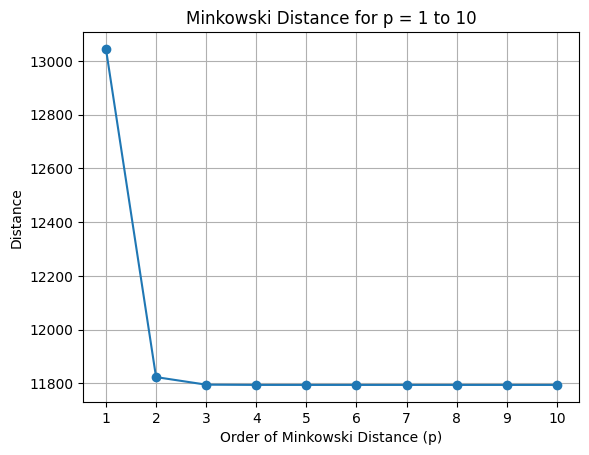

-----------------------------------------------------------------------

A6: Comparison with SciPy Minkowski Distance
p	My Function	SciPy
1	13045.000000	13045.000000
2	11823.154444	11823.154444
3	11794.961095	11794.961095
4	11794.036071	11794.036071
5	11794.001453	11794.001453
6	11794.000061	11794.000061
7	11794.000000	11794.000000
8	11794.000000	11794.000000
9	11794.000000	11794.000000
10	11794.000000	11794.000000
-----------------------------------------------------------------------

A7: Dot Product
Our function: 32
NumPy: 32

A7: Euclidean Norm of A
Our function: 3.7416573867739413
NumPy: 3.7416573867739413

A7: Euclidean Norm of B
Our function: 8.774964387392123
NumPy: 8.774964387392123
-----------------------------------------------------------------------

A8: Dataset Statistics
                             Mean      Variance  Standard Deviation
ID                    5592.159821  1.053611e+07         3245.937415
Year_Birth            1968.805804  1.435538e+02           11.981394

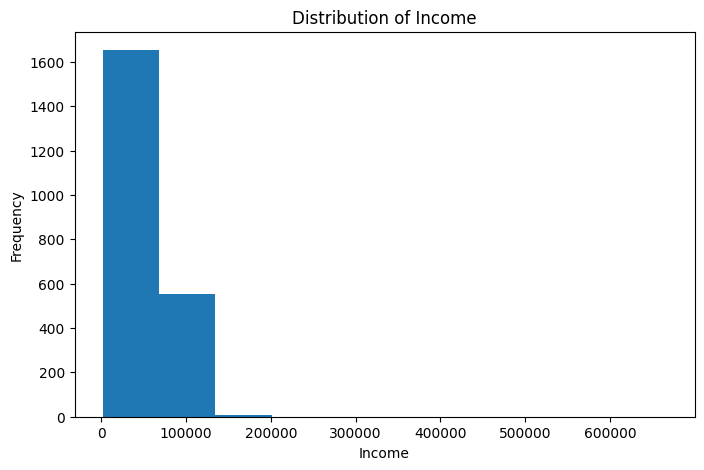


A11: K-Means Clustering
Number of clusters: 3
Number of iterations: 22
Centroids:
[[7.95317612e+04 6.33563847e+02]
 [5.43643587e+04 3.22766908e+02]
 [2.90555006e+04 3.41312102e+01]]

Cluster assignments:
[1 1 0 ... 1 0 1]


In [ ]:
# Function Call of all questions

#A1
result = classify_Features(df)

print("A1: Feature Measurement Types")
print(result.to_string(index=False))

print("-----------------------------------------------------------------------")
#A2
education_encoded = Label_encode(df, "Education")

print("A2: Label Encoding")
print(education_encoded[:5])

marital_encoded = one_hot_encode(df, "Marital_Status")

print("A2: One-Hot Encoding")
print(marital_encoded.head())

print("-----------------------------------------------------------------------")
#A3
encoded_df =  Encode_dataset(df)

print("A3: Feature Dimensionality")
print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", encoded_df.shape)
print("Increase in features:", encoded_df.shape[1] - df.shape[1])


print("-----------------------------------------------------------------------")
#A4
point1 = [1, 2, 3]
point2 = [4, 6, 8]

manhattan = minkowski_distance(point1, point2, 1)
euclidean = minkowski_distance(point1, point2, 2)

print("\nA4: Minkowski Distance")
print("Manhattan Distance:", manhattan)
print("Euclidean Distance:", euclidean)


#A5 - With the help of chatgpt
print("-----------------------------------------------------------------------")
features = ["Income", "MntWines", "MntFruits", "MntMeatProducts"]

vector1 = df.loc[0, features].values
vector2 = df.loc[1, features].values

p_values = range(1, 11)
distances = []

for p in p_values:
    distance = minkowski_distance(vector1, vector2, p)
    distances.append(distance)

print("\nA5: Minkowski Distance for p = 1 to 10")
for p, distance in zip(p_values, distances):
    print(f"p = {p}: {distance}")

import matplotlib.pyplot as plt

plt.plot(p_values, distances, marker="o")
plt.xlabel("Order of Minkowski Distance (p)")
plt.ylabel("Distance")
plt.title("Minkowski Distance for p = 1 to 10")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


#A6  - With the help of chatgpt
print("-----------------------------------------------------------------------")
from scipy.spatial.distance import minkowski as scipy_minkowski

p_values = range(1, 11)
my_distances = []
scipy_distances = []

for p in p_values:
    my_distance = minkowski_distance(vector1, vector2, p)
    scipy_distance = scipy_minkowski(vector1, vector2, p)

    my_distances.append(my_distance)
    scipy_distances.append(scipy_distance)

print("\nA6: Comparison with SciPy Minkowski Distance")
print("p\tMy Function\tSciPy")

for p, my_d, scipy_d in zip(p_values, my_distances, scipy_distances):
    print(f"{p}\t{my_d:.6f}\t{scipy_d:.6f}")


print("-----------------------------------------------------------------------")

#A7
A = [1, 2, 3]
B = [4, 5, 6]

my_dot = Dot_product(A, B)
numpy_dot = np.dot(A, B)

my_norm_A = euclidean_Norm(A)
numpy_norm_A = np.linalg.norm(A)

my_norm_B = euclidean_Norm(B)
numpy_norm_B = np.linalg.norm(B)

print("\nA7: Dot Product")
print("Our function:", my_dot)
print("NumPy:", numpy_dot)

print("\nA7: Euclidean Norm of A")
print("Our function:", my_norm_A)
print("NumPy:", numpy_norm_A)

print("\nA7: Euclidean Norm of B")
print("Our function:", my_norm_B)
print("NumPy:", numpy_norm_B)


print("-----------------------------------------------------------------------")

# A8
statistics = calculate_dataset_statistics(df)

print("\nA8: Dataset Statistics")
print(statistics)

print("-----------------------------------------------------------------------")

# A9
numeric_data = df.select_dtypes(include="number")
feat_vecs = numeric_data.to_numpy()

numpy_mean = np.mean(feat_vecs, axis=0)
numpy_std = np.std(feat_vecs, axis=0)

my_mean = statistics["Mean"].to_numpy()
my_std = statistics["Standard Deviation"].to_numpy()

print("\nA9: Mean Comparison")
for i, column in enumerate(numeric_data.columns):
    print(f"{column}: My Function = {my_mean[i]:.6f}, NumPy = {numpy_mean[i]:.6f}")

print("\nA9: Standard Deviation Comparison")
for i, column in enumerate(numeric_data.columns):
    print(f"{column}: My Function = {my_std[i]:.6f}, NumPy = {numpy_std[i]:.6f}")

print("-----------------------------------------------------------------------")

#A10
feature = df["Income"].dropna().to_numpy()

hist, bins = np.histogram(feature, bins=10)

mean_income = calculate_mean(feature)
variance_income = calculate_variance(feature)

print("\nA10: Income Distribution")
print("Histogram frequencies:", hist)
print("Bucket boundaries:", bins)
print("Mean:", mean_income)
print("Variance:", variance_income)

plt.figure(figsize=(8, 5))
plt.hist(feature, bins=10)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Distribution of Income")
plt.show()


#A11

features = ["Income", "MntWines"]

kmeans_data = df[features].dropna().to_numpy()

clusters, centroids, iterations = k_means(kmeans_data, k=3)

print("\nA11: K-Means Clustering")
print("Number of clusters:", 3)
print("Number of iterations:", iterations)
print("Centroids:")
print(centroids)

print("\nCluster assignments:")
print(clusters)